# 🧬 Skip-Gram & Word2Vec — from one-hot symbols to vectors with meaning

So far the course has handled words as **discrete symbols**: an n-gram model
asks how often the bigram `("the", "king")` appears, and a hidden Markov model
shuffles between a small set of latent states. Both are symbolic systems —
no `(the, king)` is "near" any other pair; there is no geometry.

This notebook builds the first model in our course that gives meaning a
**geometry**: every word becomes a point in $\mathbb{R}^D$, and similar words
land near each other. We will:

1. State the **distributional hypothesis** that makes the geometry possible.
2. Derive the **skip-gram** equations (forward pass, cross-entropy loss,
   gradients) from scratch.
3. Implement skip-gram in pure NumPy on a toy corpus — to see the math run.
4. Discover why the toy version cannot scale, and add the two tricks that
   make Word2Vec actually work: **subsampling** of frequent words and
   **negative sampling** of context targets.
5. Train a real model on the **NLTK Brown corpus** (~1M tokens) and inspect
   the learned vector neighbourhoods.
6. Load a **pretrained GloVe** model (trained on billions of words) and run
   the classic analogy:
   $$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$
7. Close on what static embeddings **still cannot** capture — the bank/bank
   problem that motivates the contextual embeddings of Unit 4.

📜 The papers in this folder — Mikolov et al. (2013), *Efficient Estimation of
Word Representations* and *Distributed Representations of Words and Phrases* —
are the original Word2Vec papers; the notebook follows their formulation.


In [1]:
# ----------------------------------------------------------
# Setup — runs in Google Colab and locally without changes.
# ----------------------------------------------------------

# Detect Colab. The `google.colab` module is importable on Colab and
# nowhere else; we use that as our env flag.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"IN_COLAB = {IN_COLAB}")

# Install gensim if it's missing. Colab dropped gensim from its base image
# around 2023, and we need it for the pretrained-GloVe loader near the end of
# the notebook. nltk, scikit-learn, numpy, and matplotlib are pre-installed
# on Colab so we don't touch them.
import importlib.util, subprocess, sys

if importlib.util.find_spec("gensim") is None:
    print("Installing gensim ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gensim"], check=True)

# SSL workaround for macOS Python installs whose system certificate bundle is
# broken. Harmless on Colab. Lets `nltk.download(...)` and
# `gensim.downloader.load(...)` reach their CDNs without certificate errors.
import ssl
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except AttributeError:
    pass

# ---- Run-mode flags ----
# SMOKE_TEST cuts the SGNS training down to a small slice of Brown + 1 epoch,
# so the whole notebook finishes in well under a minute. Flip to False for the
# real run (3 epochs on all of Brown, ~100s on a laptop CPU, ~150-200s on
# Colab CPU).
SMOKE_TEST      = False

# AUTO_DISCONNECT makes the very last cell disconnect the Colab runtime when
# the notebook finishes (to stop billing on Colab Pro). Off by default so a
# student iterating doesn't get kicked out mid-session.
AUTO_DISCONNECT = False

print(f"SMOKE_TEST      = {SMOKE_TEST}")
print(f"AUTO_DISCONNECT = {AUTO_DISCONNECT}")


IN_COLAB = False
SMOKE_TEST      = False
AUTO_DISCONNECT = False


## 🌐 The distributional hypothesis

> *"You shall know a word by the company it keeps."* — J. R. Firth, 1957

The intuition behind every embedding model in this notebook is that **words
that appear in similar contexts tend to have similar meanings**. If we see
`bank` next to *interest*, *loan*, *account*, and `credit` next to those same
words, we should conclude that *bank* and *credit* are semantically related —
even though as strings they share nothing.

**Philosophical note.** This is a *use-theoretic* commitment about meaning:
meaning is something that emerges from co-occurrence patterns, not from
referential ties to mind-independent objects. The skip-gram architecture below
operationalises this exactly: each word is the vector that best predicts the
words it tends to appear with.


## 🧠 Skip-Gram model architecture and forward pass

Skip-gram is a **shallow neural network** that, given a *center* word, tries
to predict the **context** words inside a sliding window around it. The
embeddings we want are the **weights** of this network — training is just a
device to learn them.

### 🏗️ Matrix dimensions

- $V$: vocabulary size
- $D$: embedding dimension (a hyperparameter — typically 50–300)
- $x \in \mathbb{R}^V$: one-hot vector for the center word
- $W_1 \in \mathbb{R}^{V \times D}$: input-to-hidden weight matrix (one row per word — these are the *embeddings*)
- $W_2 \in \mathbb{R}^{D \times V}$: hidden-to-output matrix (one column per word — sometimes called the *context* matrix)

### 📤 Forward pass

**1. Hidden layer (embedding lookup).** Project the one-hot $x$ into embedding space:

$$
h = W_1^\top x \in \mathbb{R}^D
$$

Because $x$ is one-hot, this just *selects a row of $W_1$* — there is no real
matrix multiply happening at training time. The hidden layer **is** the embedding.

**2. Output logits.** Score every word in the vocabulary as a potential context word:

$$
u = W_2^\top h \in \mathbb{R}^V
$$

**3. Softmax.** Normalise to a distribution over context words:

$$
\hat y_i = \frac{\exp(u_i)}{\sum_{j=1}^{V} \exp(u_j)}
$$

### 🧠 Interpretation

- $h$ **is** the embedding of the center word.
- $\hat y$ is the model's belief about which words live around it.
- $W_1$ ("input embeddings") and $W_2$ ("output embeddings") are *different
  vectors for the same word*. People usually take $W_1$ at the end of training
  as the actual word vector, but in negative-sampling training both matter.


## 🔄 Cross-entropy loss and gradients

For a (center, context) training pair $(w_c, w_o)$, encode the truth $y$ as a
one-hot vector with a $1$ in slot $w_o$. The loss is **cross-entropy** between
$y$ and $\hat y$:

$$
\mathcal{L} \;=\; -\sum_{i=1}^{V} y_i \log \hat y_i \;=\; -\log \hat y_{w_o}
$$

A small bit of algebra shows the gradient w.r.t. the logits is just the
prediction error:

$$
e \;=\; \hat y - y \;\in\; \mathbb{R}^V
$$

From there, the gradients of $W_2$ and $W_1$ are outer products:

$$
\frac{\partial \mathcal{L}}{\partial W_2} = h \, e^\top
\qquad\qquad
\frac{\partial \mathcal{L}}{\partial W_1} = x \,(W_2 e)^\top
$$

and we update with SGD: $W \leftarrow W - \eta \,\partial \mathcal{L}/\partial W$.

### 📝 Training step recap

For each (center, context) pair:
1. One-hot encode the center: $x$
2. $h = W_1^\top x$  *(embedding lookup)*
3. $u = W_2^\top h$  *(scores)*
4. $\hat y = \text{softmax}(u)$  *(probabilities)*
5. $\mathcal{L} = -\log \hat y_{\text{context}}$
6. Backprop: compute $e = \hat y - y$, then the outer-product gradients above
7. SGD update on $W_1$ and $W_2$

### ⚠️ The bottleneck

The full softmax in step 4 normalises over the **entire vocabulary** — that's
$O(V)$ work per gradient step. For a real corpus with $V \approx 50{,}000$ this
is catastrophic. We'll fix it in the *Negative Sampling* section below.


In [2]:
# ----------------------------------------------------------
# Skip-Gram in pure NumPy — toy corpus, full softmax
# ----------------------------------------------------------
# This is the textbook implementation: every gradient step normalises over
# the whole vocabulary. It's slow but transparent — useful for understanding
# what the equations *do* before we replace them with the negative-sampling
# trick in the next section.

import numpy as np
import re

# 1) Tokenisation: lower-case, strip punctuation, split on whitespace.
def tokenize_corpus(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

# 2) Vocabulary: stable sorted set of unique tokens, plus index maps.
def build_vocab(tokens):
    vocab = sorted(set(tokens))
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word

# 3) Training pairs: (center, context) for every word within `window_size` of
#    every other word. Indexed by integer ids, not strings.
def generate_training_data(tokens, window_size=2):
    word2idx, _ = build_vocab(tokens)
    pairs = []
    for i, center in enumerate(tokens):
        lo = max(0, i - window_size)
        hi = min(len(tokens), i + window_size + 1)
        for j in range(lo, hi):
            if j != i:
                pairs.append((word2idx[center], word2idx[tokens[j]]))
    return pairs, word2idx


class SkipGramModel:
    # Full-softmax skip-gram. One Python loop per pair, one full softmax
    # per pair: fine for ~10 words, hopeless for a real corpus.

    def __init__(self, vocab_size, embedding_dim=10, learning_rate=0.01, seed=0):
        rng = np.random.default_rng(seed)
        self.V = vocab_size
        self.D = embedding_dim
        self.lr = learning_rate
        # Small random init so logits start near zero.
        self.W1 = rng.standard_normal((vocab_size, embedding_dim)) * 0.01
        self.W2 = rng.standard_normal((embedding_dim, vocab_size)) * 0.01

    @staticmethod
    def softmax(z):
        # Numerically stable: subtract max before exponentiating.
        e = np.exp(z - z.max())
        return e / e.sum()

    def forward(self, x):
        h = self.W1.T @ x        # (D,)  — embedding lookup
        u = self.W2.T @ h        # (V,)  — output logits
        return self.softmax(u), h

    def backprop(self, x, h, y_pred, y_true):
        e = y_pred - y_true                     # (V,) — prediction error
        dW2 = np.outer(h, e)                    # (D, V)
        dW1 = np.outer(x, self.W2 @ e)          # (V, D)
        self.W1 -= self.lr * dW1
        self.W2 -= self.lr * dW2

    def train(self, pairs, epochs=1000, print_every=100):
        for epoch in range(epochs):
            loss = 0.0
            for c_idx, o_idx in pairs:
                x = np.zeros(self.V); x[c_idx] = 1
                y_true = np.zeros(self.V); y_true[o_idx] = 1
                y_pred, h = self.forward(x)
                loss -= np.log(y_pred[o_idx] + 1e-9)
                self.backprop(x, h, y_pred, y_true)
            if epoch % print_every == 0:
                print(f"  epoch {epoch:4d}  loss={loss:.3f}")


# ----------------------------------------------------------
# Demo on a 9-word corpus
# ----------------------------------------------------------
corpus = "the quick brown fox jumps over the lazy dog"
tokens = tokenize_corpus(corpus)
print("Tokens:", tokens)

pairs, word2idx = generate_training_data(tokens, window_size=2)
print(f"Generated {len(pairs)} (center, context) pairs")
print("First 6 pairs (as indices):", pairs[:6])

print("\nTraining the toy model (1000 epochs):")
model = SkipGramModel(vocab_size=len(word2idx), embedding_dim=8, learning_rate=0.05, seed=0)
model.train(pairs, epochs=1000, print_every=200)

# Each row of W1 is the embedding for the corresponding word.
embeddings = model.W1
print("\nEmbedding for 'fox':", np.round(embeddings[word2idx['fox']], 3))
print("Embedding for 'dog':", np.round(embeddings[word2idx['dog']], 3))


Tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
Generated 30 (center, context) pairs
First 6 pairs (as indices): [(7, 6), (7, 0), (6, 7), (6, 0), (6, 2), (0, 7)]

Training the toy model (1000 epochs):
  epoch    0  loss=62.383
  epoch  200  loss=46.578
  epoch  400  loss=46.643
  epoch  600  loss=46.650
  epoch  800  loss=46.643

Embedding for 'fox': [-0.422 -1.216 -0.346  0.059  0.468  0.677 -0.297 -1.224]
Embedding for 'dog': [ 0.719  1.122  0.153 -0.162 -1.989 -0.815  0.456  1.033]


## 🛑 Why the toy isn't enough

That code is *correct*, but its outputs are not meaningful. With nine words,
there is no statistical regularity to learn — every word co-occurs with every
other word at roughly the same rate. Embedding `fox` close to `dog` *might*
happen by accident, but we are not seeing the **distributional hypothesis at
work**, just a tiny SGD trajectory.

To get real geometry we need:

1. **A real corpus** — millions of tokens, real co-occurrence statistics. We'll
   use NLTK's **Brown corpus** (~1M tokens of edited American English from the
   1960s).
2. **A faster training loss.** The full softmax over $V \approx 8{,}000$ is far
   too slow for a million-pair training set. We'll replace it with
   **negative sampling**.
3. **Frequent-word subsampling.** Words like *the*, *of*, *a* dominate every
   context window without telling us anything semantic. Word2Vec randomly drops
   them in proportion to their frequency.


## ⚡ Negative sampling — replacing the softmax

Instead of asking *"out of the entire vocabulary, which word is the context?"*
(a hard $V$-way classification), we ask *"is this pair $(w_c, w_o)$ a real
co-occurrence, or did I make it up?"* — a single sigmoid output. For each
real positive pair we sample **$k$ negative pairs** by drawing context words
from a noise distribution $P_n$, and train a binary classifier.

The Word2Vec loss for one (center, context) pair becomes:

$$
\mathcal{L}_{\text{SGNS}}(w_c, w_o)
\;=\; -\log \sigma(\mathbf{v}_{w_o}^{\,\prime\top}\, \mathbf{v}_{w_c})
\;-\; \sum_{j=1}^{k} \mathbb{E}_{w_j \sim P_n}\!\big[\log \sigma(-\mathbf{v}_{w_j}^{\,\prime\top}\, \mathbf{v}_{w_c})\big]
$$

where $\sigma$ is the logistic sigmoid, $\mathbf{v}_w$ is the *input* embedding
(a row of $W_1$), and $\mathbf{v}_w^{\,\prime}$ is the *output* embedding (a row
of $W_2$). Read the two terms as:

- **Push together** the center vector and the true context's output vector.
- **Push apart** the center vector and each negative's output vector.

### 🎲 The noise distribution

Mikolov et al. found that drawing negatives from the **unigram distribution
raised to the 3/4 power** works best:

$$
P_n(w) \;\propto\; f(w)^{3/4}
$$

The exponent $3/4$ flattens the distribution slightly — frequent words still
get sampled often, but rare words get sampled more often than their raw
frequency would suggest. This gives the model more chances to push rare words
away from incorrect contexts.

### 💧 Subsampling of frequent words

Independent of the above, before generating training pairs each token $w$ is
**discarded** with probability

$$
P_{\text{drop}}(w) \;=\; 1 - \sqrt{\frac{t}{f(w)}}
$$

where $f(w)$ is the empirical frequency and $t \approx 10^{-4}$ is a threshold.
*the*, *of*, *and* get aggressively thrown away; rare content words are kept
with probability 1. This both speeds up training and improves the quality of
the resulting embeddings (the model spends its capacity on informative pairs).

The cells below implement all of this in NumPy. Mini-batched matrix operations
make it fast enough to train on the full Brown corpus in a few minutes.


In [3]:
# ----------------------------------------------------------
# Load and clean the NLTK Brown corpus (~1M tokens).
# ----------------------------------------------------------
# The SSL workaround in the Setup cell above lets nltk.download() reach its
# CDN on macOS Python installs whose certificate bundle is broken.

import nltk
nltk.download('brown', quiet=True)
from nltk.corpus import brown

# Keep only alphabetic tokens, lower-cased. Brown has its own tokenisation, so
# we don't run a tokenizer over it — we just filter.
raw_tokens = [w.lower() for w in brown.words() if w.isalpha()]
print(f"Raw alphabetic tokens in Brown: {len(raw_tokens):,}")

# Smoke-test mode: train on a small slice so the rest of the notebook (vocab,
# pair generation, training) runs in a few seconds instead of a few minutes.
# Set SMOKE_TEST = False in the Setup cell for the real run.
if SMOKE_TEST:
    raw_tokens = raw_tokens[:100_000]
    print(f"SMOKE_TEST=True → capped to {len(raw_tokens):,} tokens.")

print(f"First 20 tokens: {raw_tokens[:20]}")


Raw alphabetic tokens in Brown: 981,716
First 20 tokens: ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took']


In [4]:
# ----------------------------------------------------------
# Vocabulary, subsampling probabilities, negative-sampling table.
# ----------------------------------------------------------
import numpy as np
from collections import Counter

MIN_COUNT      = 10        # drop any word seen fewer than 10 times
EMB_DIM        = 100       # dimension D of the embedding space
WINDOW         = 5         # max context window radius
SUBSAMPLE_T    = 1e-4      # Mikolov's subsampling threshold
NEG_K          = 5         # number of negatives per positive pair
NEG_POWER      = 0.75      # exponent on the unigram noise distribution
NEG_TABLE_SIZE = 1_000_000 # precomputed alias-style sampling table
LEARNING_RATE  = 0.025
BATCH_SIZE     = 1024
EPOCHS         = 1 if SMOKE_TEST else 3   # SMOKE_TEST keeps the cell under a minute
SEED           = 42

rng = np.random.default_rng(SEED)

# 1) Frequency-filtered vocabulary.
counts = Counter(raw_tokens)
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = vocab  # list doubles as idx→word
V = len(vocab)
print(f"Vocabulary size (min_count={MIN_COUNT}): V = {V:,}")
print("Top 10 by frequency:", [(w, counts[w]) for w in vocab[:10]])

# Sanity check: are our probe words present, and do they have non-trivial counts?
for w in ("king", "queen", "man", "woman", "money", "war", "love", "music"):
    print(f"  count({w!r}) = {counts.get(w, 0)}")

# 2) Filter the corpus to in-vocab token ids.
token_ids = np.array([word2idx[w] for w in raw_tokens if w in word2idx])
print(f"\nFiltered token count: {len(token_ids):,}")

# 3) Empirical frequencies (over the filtered corpus).
freqs = np.bincount(token_ids, minlength=V).astype(np.float64)
freqs /= freqs.sum()

# 4) Mikolov subsampling: keep probability per word.
#    Keep ≈ 1 for rare content words; aggressively drop very frequent ones.
keep_prob = np.minimum(1.0, np.sqrt(SUBSAMPLE_T / freqs))
print(f"\nSubsampling keep-probabilities:")
for w in ("the", "of", "and", "king", "queen", "philosophy"):
    if w in word2idx:
        print(f"  keep_prob({w!r}) = {keep_prob[word2idx[w]]:.4f}")

# 5) Negative-sampling distribution P_n(w) ∝ f(w)^{0.75}.
#    Precompute a big array of sampled indices so each draw is an O(1) lookup.
neg_probs = freqs ** NEG_POWER
neg_probs /= neg_probs.sum()
neg_table = rng.choice(V, size=NEG_TABLE_SIZE, p=neg_probs)
print(f"\nNegative-sampling table built ({NEG_TABLE_SIZE:,} entries).")


Vocabulary size (min_count=10): V = 8,143
Top 10 by frequency: [('the', 69971), ('of', 36412), ('and', 28853), ('to', 26158), ('a', 23195), ('in', 21337), ('that', 10594), ('is', 10109), ('was', 9815), ('he', 9548)]
  count('king') = 88
  count('queen') = 41
  count('man') = 1207
  count('woman') = 224
  count('money') = 265
  count('war') = 464
  count('love') = 231
  count('music') = 216

Filtered token count: 901,384

Subsampling keep-probabilities:
  keep_prob('the') = 0.0359
  keep_prob('of') = 0.0498
  keep_prob('and') = 0.0559
  keep_prob('king') = 1.0000
  keep_prob('queen') = 1.0000
  keep_prob('philosophy') = 1.0000

Negative-sampling table built (1,000,000 entries).


In [5]:
# ----------------------------------------------------------
# Generate (center, context) pairs with dynamic window + subsampling.
# ----------------------------------------------------------
# Word2Vec uses a *dynamic* window: for each center word it picks an actual
# window size uniformly from [1, WINDOW]. This implicitly weights nearby
# context words more (they appear in more dynamic windows).
import time

def make_pairs(seq, window):
    # Drop tokens with probability 1 - keep_prob[id]; keeps content, dumps "the".
    keep_mask = rng.random(len(seq)) < keep_prob[seq]
    kept = seq[keep_mask]

    centers, contexts = [], []
    for i, c in enumerate(kept):
        w = rng.integers(1, window + 1)  # dynamic window size
        lo, hi = max(0, i - w), min(len(kept), i + w + 1)
        for j in range(lo, hi):
            if j != i:
                centers.append(c)
                contexts.append(kept[j])
    return np.asarray(centers), np.asarray(contexts)


t0 = time.time()
centers, contexts = make_pairs(token_ids, WINDOW)
print(f"Generated {len(centers):,} training pairs in {time.time()-t0:.1f}s")
print(f"Example pairs (as words):")
for i in range(5):
    print(f"  ({idx2word[centers[i]]!r:>14}, {idx2word[contexts[i]]!r:<14})")


Generated 2,334,581 training pairs in 2.3s
Example pairs (as words):
  (      'fulton', 'county'      )
  (      'fulton', 'grand'       )
  (      'fulton', 'jury'        )
  (      'fulton', 'friday'      )
  (      'county', 'fulton'      )


In [6]:
# ----------------------------------------------------------
# Skip-Gram with Negative Sampling — pure NumPy, mini-batched SGD.
# ----------------------------------------------------------
# Key observation: every step is just dot products + a sigmoid + a scatter-add
# into two embedding matrices. No autograd, no special tricks beyond
# np.einsum and np.add.at. Trains in a couple of minutes on a laptop.

def sigmoid(x):
    # Clip the argument to avoid overflow in exp(-x) for very large positive x.
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

# Initialise: input embeddings small & random, output embeddings at 0 (the
# trick from the original word2vec implementation).
W_in  = (rng.random((V, EMB_DIM)) - 0.5) / EMB_DIM
W_out = np.zeros((V, EMB_DIM))

n_pairs = len(centers)
print(f"Training SGNS: V={V}, D={EMB_DIM}, pairs={n_pairs:,}, "
      f"k={NEG_K}, batch={BATCH_SIZE}, epochs={EPOCHS}")

loss_history = []
t0 = time.time()
for epoch in range(EPOCHS):
    perm = rng.permutation(n_pairs)
    epoch_loss, n_batches = 0.0, 0

    for start in range(0, n_pairs, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_pairs)
        b_centers  = centers[perm[start:end]]
        b_contexts = contexts[perm[start:end]]
        B = len(b_centers)

        # Draw k negatives per positive — uniform indices into the precomputed
        # noise table (each entry is already distributed as f^0.75).
        neg_samples = neg_table[rng.integers(0, NEG_TABLE_SIZE, size=(B, NEG_K))]

        v_c   = W_in[b_centers]              # (B, D)
        v_pos = W_out[b_contexts]            # (B, D)
        v_neg = W_out[neg_samples]           # (B, K, D)

        s_pos = (v_c * v_pos).sum(axis=1)            # (B,)
        s_neg = np.einsum("bkd,bd->bk", v_neg, v_c)  # (B, K)

        # Loss for logging (mean over batch).
        pos_loss = -np.log(sigmoid(s_pos) + 1e-10)
        neg_loss = -np.log(sigmoid(-s_neg) + 1e-10).sum(axis=1)
        epoch_loss += (pos_loss + neg_loss).mean()
        n_batches  += 1

        # Gradients (these come from d/dx of log sigmoid).
        g_pos = sigmoid(s_pos) - 1.0   # (B,)
        g_neg = sigmoid(s_neg)         # (B, K)

        grad_v_c   = g_pos[:, None] * v_pos + np.einsum("bk,bkd->bd", g_neg, v_neg)
        grad_v_pos = g_pos[:, None] * v_c
        grad_v_neg = g_neg[:, :, None] * v_c[:, None, :]

        # Scatter-add into the global parameter matrices (centers / positive
        # contexts / negative contexts can repeat within a batch — np.add.at
        # accumulates correctly when they do).
        np.add.at(W_in,  b_centers,                    -LEARNING_RATE * grad_v_c)
        np.add.at(W_out, b_contexts,                   -LEARNING_RATE * grad_v_pos)
        np.add.at(W_out, neg_samples.reshape(-1),
                  -LEARNING_RATE * grad_v_neg.reshape(-1, EMB_DIM))

    mean_loss = epoch_loss / n_batches
    loss_history.append(mean_loss)
    print(f"  epoch {epoch}: mean batch loss = {mean_loss:.4f}   "
          f"elapsed = {time.time()-t0:.1f}s")

print("\nTraining complete.")


Training SGNS: V=8143, D=100, pairs=2,334,581, k=5, batch=1024, epochs=3
  epoch 0: mean batch loss = 2.8682   elapsed = 36.0s
  epoch 1: mean batch loss = 2.6254   elapsed = 73.7s
  epoch 2: mean batch loss = 2.5736   elapsed = 112.5s

Training complete.


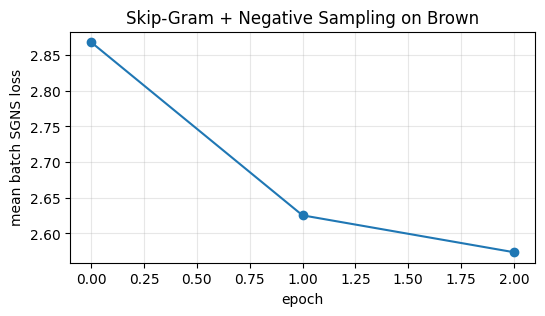

In [7]:
# Quick loss-curve plot — should be monotonically decreasing.
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(loss_history, marker='o')
plt.xlabel("epoch")
plt.ylabel("mean batch SGNS loss")
plt.title("Skip-Gram + Negative Sampling on Brown")
plt.grid(alpha=0.3)
plt.show()


In [8]:
# ----------------------------------------------------------
# Cosine-similarity neighbourhoods over our learned embeddings.
# ----------------------------------------------------------
# We use W_in as the "word vector". (Some implementations average W_in + W_out;
# both options are reasonable.) Pre-normalise once for fast cosine lookups.

W = W_in
W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-10)

def nearest(word, k=8):
    if word not in word2idx:
        return f"{word!r} not in vocab"
    v = W_norm[word2idx[word]]
    sims = W_norm @ v
    top = np.argsort(-sims)[:k + 1]
    return [(idx2word[i], float(sims[i])) for i in top if idx2word[i] != word][:k]

for probe in ("king", "money", "war", "river", "love", "city", "music", "doctor"):
    nbrs = nearest(probe, 8)
    if isinstance(nbrs, str):
        print(nbrs); continue
    pretty = ", ".join(f"{w}({s:.2f})" for w, s in nbrs)
    print(f"  {probe:<8} → {pretty}")


  king     → played(0.96), gorton(0.96), honor(0.96), fought(0.95), peter(0.95), pike(0.95), arthur(0.94), letter(0.94)
  money    → full(0.89), buy(0.88), help(0.87), vacation(0.87), pay(0.87), make(0.87), your(0.86), doctor(0.86)
  war      → europe(0.93), soviet(0.92), british(0.90), declared(0.90), western(0.89), democratic(0.88), german(0.88), civil(0.88)
  river    → bay(0.97), avenue(0.96), across(0.95), white(0.95), buildings(0.95), sugar(0.95), blue(0.94), street(0.94)
  love     → suffering(0.96), salvation(0.96), knows(0.95), escape(0.95), soul(0.95), anyone(0.95), feels(0.95), aware(0.95)
  city     → league(0.92), park(0.92), york(0.91), francisco(0.90), chicago(0.90), club(0.90), philadelphia(0.89), elected(0.89)
  music    → style(0.95), musical(0.92), jazz(0.91), primitive(0.91), english(0.91), dramatic(0.91), contemporary(0.91), poetry(0.91)
  doctor   → stay(0.97), send(0.95), carla(0.95), folks(0.95), leave(0.95), ready(0.94), tomorrow(0.94), promised(0.94)


Plotting: ['king', 'queen', 'prince', 'lord', 'hand', 'eye', 'head', 'heart', 'day', 'night', 'year', 'morning', 'evening', 'city', 'town', 'country', 'world']


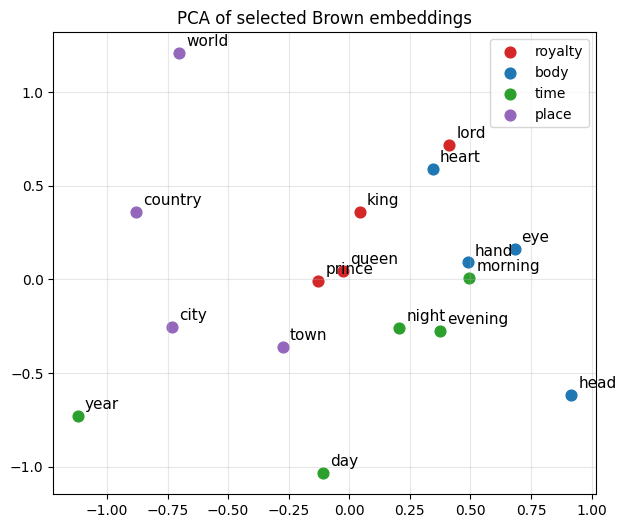

In [9]:
# ----------------------------------------------------------
# PCA scatter of a few hand-picked words — does the geometry make sense?
# ----------------------------------------------------------
# Brown's vocabulary is small and dated, so we pick words that *should*
# cluster: countries, body parts, animals, time, and a "royalty" cluster.
from sklearn.decomposition import PCA

groups = {
    "royalty": ["king", "queen", "prince", "lord"],
    "body":    ["hand", "eye", "head", "heart"],
    "time":    ["day", "night", "year", "morning", "evening"],
    "place":   ["city", "town", "country", "world"],
}
words = [w for ws in groups.values() for w in ws if w in word2idx]
print("Plotting:", words)
vecs = np.array([W[word2idx[w]] for w in words])

xy = PCA(n_components=2, random_state=0).fit_transform(vecs)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))
colors = {"royalty": "tab:red", "body": "tab:blue",
          "time": "tab:green", "place": "tab:purple"}
for group, group_words in groups.items():
    pts = [(xy[words.index(w)]) for w in group_words if w in words]
    if not pts: continue
    xs, ys = zip(*pts)
    plt.scatter(xs, ys, color=colors[group], label=group, s=60)
    for x, y, w in zip(xs, ys, [w for w in group_words if w in words]):
        plt.annotate(w, (x, y), fontsize=11, xytext=(5, 5), textcoords="offset points")
plt.title("PCA of selected Brown embeddings")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 📏 Honest reckoning: what 1M tokens buys us

Look at the nearest-neighbour output above. Some queries land cleanly
(`money → pay, spend, cost`, `war → britain, european, civil`), others are
noisy. With only ~1M tokens the model has seen *king* fewer than 100 times —
not enough to triangulate it tightly against *queen*, *prince*, *throne*.

What it *does* show is that the geometry is **non-random**: words from related
domains do tend to cluster. The distributional hypothesis is doing something.

For the famous king − man + woman ≈ queen analogy, we need vectors trained on
**a much larger corpus**. The next cell loads **GloVe** (Pennington, Socher,
Manning 2014), pretrained on **6 billion tokens** from Wikipedia + Gigaword.
GloVe uses a slightly different objective — it factorises a log-co-occurrence
matrix rather than running a sliding window — but produces vectors of the
same flavor as Word2Vec. The analogy task is a standard intrinsic evaluation
for both.


In [10]:
# ----------------------------------------------------------
# Load pretrained GloVe vectors (Wikipedia + Gigaword, 6B tokens, 100d).
# ----------------------------------------------------------
# gensim's downloader caches the file in ~/gensim-data/. Local laptops keep
# the cache between runs; Colab's filesystem is ephemeral, so each session
# re-downloads ~134 MB. SSL is already handled in the Setup cell.

import gensim.downloader as api
glove = api.load("glove-wiki-gigaword-100")
print(f"Loaded GloVe: {len(glove.key_to_index):,} words × {glove.vector_size} dims")


Loaded GloVe: 400,000 words × 100 dims


In [11]:
# ----------------------------------------------------------
# The wow demo: vector arithmetic on GloVe.
# ----------------------------------------------------------
# `most_similar(positive=[A, B], negative=[C])` returns the words whose vectors
# are closest (by cosine) to A + B − C. The classic case below should print
# 'queen' as the top result — semantics literally falling out of linear algebra.

def show_analogy(positive, negative, expected=None, k=5):
    plus  = " + ".join(positive)
    minus = " − " + " − ".join(negative) if negative else ""
    results = glove.most_similar(positive=positive, negative=negative, topn=k)
    head = f"{plus}{minus}".ljust(32)
    print(f"{head} → {[w for w, _ in results]}")
    if expected is not None:
        top = results[0][0]
        flag = "✅" if top == expected else "⚠️ "
        print(f"   {flag} top result: {top!r}   (expected {expected!r})")

print("=== Classic gender / royalty / capitals analogies ===\n")
show_analogy(["king", "woman"], ["man"], expected="queen")
show_analogy(["paris", "germany"], ["france"], expected="berlin")
show_analogy(["tokyo", "italy"], ["japan"], expected="rome")
show_analogy(["walking", "swim"], ["walk"], expected="swimming")
show_analogy(["bigger", "small"], ["big"], expected="smaller")
show_analogy(["uncle", "woman"], ["man"], expected="aunt")

print("\n=== Plain nearest neighbours in GloVe ===")
for probe in ("king", "music", "philosophy", "war", "bank"):
    print(f"  {probe:<11} → {[w for w, _ in glove.most_similar(probe, topn=8)]}")


=== Classic gender / royalty / capitals analogies ===

king + woman − man               → ['queen', 'monarch', 'throne', 'daughter', 'princess']
   ✅ top result: 'queen'   (expected 'queen')
paris + germany − france         → ['berlin', 'frankfurt', 'vienna', 'munich', 'hamburg']
   ✅ top result: 'berlin'   (expected 'berlin')
tokyo + italy − japan            → ['rome', 'milan', 'paris', 'naples', 'amsterdam']
   ✅ top result: 'rome'   (expected 'rome')
walking + swim − walk            → ['swimming', 'surfing', 'swam', 'rowing', 'jogging']
   ✅ top result: 'swimming'   (expected 'swimming')
bigger + small − big             → ['larger', 'smaller', 'large', 'tiny', 'size']
   ⚠️  top result: 'larger'   (expected 'smaller')
uncle + woman − man              → ['aunt', 'daughter', 'niece', 'grandmother', 'mother']
   ✅ top result: 'aunt'   (expected 'aunt')

=== Plain nearest neighbours in GloVe ===
  king        → ['prince', 'queen', 'son', 'brother', 'monarch', 'throne', 'kingdom', 'fathe

## 🪞 What static embeddings still cannot do — the bank/bank problem

Look at the GloVe neighbours of **bank** above: they are entirely *financial*
(`banks, banking, credit, investment, lending, ...`). There is no trace of the
*river-bank* sense — even though in actual English usage that meaning is
common. Why?

A static embedding gives **one vector per word type**, no matter the context.
When *bank* appears in the corpus next to *river* and next to *deposit*, both
signals are averaged into a single representation. Because the financial sense
is much more frequent in news + Wikipedia text, that sense dominates and the
river sense is squashed against it.

This is the fundamental limitation that motivates the next unit:

> 🧬 **Contextual embeddings** assign a *different* vector to a word for each
> sentence it appears in. *bank* in "I sat on the bank" gets a vector pulled
> toward `river`, `shore`, `grass`; *bank* in "I deposited it at the bank"
> gets pulled toward `credit`, `loan`, `account`. The same string, two
> different points in space.

The mechanism that lets you do this efficiently — **self-attention** — is the
subject of Unit 4. The vectors you trained here are the *inputs* to a
transformer; what the transformer does is rewrite each one based on the
others in the sequence.

### 📚 Going further

- 📝 **Mikolov et al. (2013a, 2013b)** — the two papers in this folder; the
  source for everything in this notebook.
- 📝 **Pennington, Socher, Manning (2014)** — *GloVe: Global Vectors for Word
  Representation* — the matrix-factorisation alternative to Word2Vec we used
  for the analogy demo.
- 📝 **Peters et al. (2018)** — *ELMo*, the first widely-used contextual
  embeddings; bridges to Unit 4.
- 📝 **Bolukbasi et al. (2016)** — *Man is to Computer Programmer as Woman is
  to Homemaker?* — a striking demonstration that the analogy structure picks
  up the corpus's biases as well as its semantics. Worth assigning before the
  next class.


In [12]:
# ----------------------------------------------------------
# Optional: disconnect the Colab runtime (paid plans).
# ----------------------------------------------------------
# Only runs when AUTO_DISCONNECT is True (set in the Setup cell at the top)
# AND we're actually inside Colab. Free Colab doesn't bill, so this is off
# by default. On Colab Pro, flip the flag so a forgotten tab doesn't keep the
# runtime warm.

if AUTO_DISCONNECT and IN_COLAB:
    from IPython.display import Javascript, display
    print("AUTO_DISCONNECT=True — disconnecting Colab runtime.")
    display(Javascript("google.colab.kernel.disconnect()"))
else:
    print(f"AUTO_DISCONNECT={AUTO_DISCONNECT}, IN_COLAB={IN_COLAB} — staying connected.")


AUTO_DISCONNECT=False, IN_COLAB=False — staying connected.
